# Feature engineering + premier modèle de prédiction — PFE

Objectif : prédire le nombre de vélos disponibles dans une station **dans le
futur** (ex: dans 30 minutes), à partir de son historique récent.

On construit ici :
1. Les features (variables d'entrée du modèle)
2. Un modèle **baseline** (le plus simple possible, sert de référence)
3. Un modèle **XGBoost** (plus performant, on compare aux baseline)

Note : avec seulement quelques heures/jours d'historique, les résultats
seront indicatifs. Ce notebook est fait pour être **relancé régulièrement**
au fur et à mesure que la collecte (conteneur Docker `ingestion`) accumule
plus de données — plus il y a d'historique, meilleur sera le modèle.

In [9]:
import os
import pandas as pd
import numpy as np
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()
DB_URL = (
    f"postgresql+psycopg2://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}"
    f"@{os.environ['DB_HOST']}:{os.environ['DB_PORT']}/{os.environ['DB_NAME']}"
)
engine = create_engine(DB_URL)

df = pd.read_sql("""
    select station_id, collected_at, num_bikes_available, num_docks_available
    from dbt_dev.silver_station_status
    order by station_id, collected_at
""", engine, parse_dates=["collected_at"])
print(f"{len(df):,} lignes, {df['station_id'].nunique()} stations, "
      f"{df['collected_at'].nunique()} instants de collecte")

53,031 lignes, 1516 stations, 35 instants de collecte


## 1. Construction des features

Pour chaque ligne (station, instant T), on ajoute :
- l'heure et le jour de la semaine
- le nombre de vélos disponibles il y a 1, 2 et 3 collectes (lags)
- la **cible** (target) : le nombre de vélos disponibles à la PROCHAINE collecte
  (c'est ce qu'on veut prédire)

In [10]:
HORIZON = 1  # on prédit 1 pas de collecte dans le futur (~5-15 min selon la fréquence réelle)
N_LAGS = 3

df = df.sort_values(["station_id", "collected_at"]).reset_index(drop=True)

df["hour"] = df["collected_at"].dt.hour
df["day_of_week"] = df["collected_at"].dt.dayofweek

# Lags : valeurs passées, par station
for lag in range(1, N_LAGS + 1):
    df[f"lag_{lag}"] = df.groupby("station_id")["num_bikes_available"].shift(lag)

# Target : valeur future, par station
df["target"] = df.groupby("station_id")["num_bikes_available"].shift(-HORIZON)

# On garde uniquement les lignes complètes (assez d'historique avant ET après)
features = ["hour", "day_of_week"] + [f"lag_{lag}" for lag in range(1, N_LAGS + 1)]
dataset = df.dropna(subset=features + ["target"]).copy()

print(f"Dataset final utilisable : {len(dataset):,} lignes (sur {len(df):,} lignes brutes)")
dataset[["station_id", "collected_at"] + features + ["target"]].head()

Dataset final utilisable : 46,967 lignes (sur 53,031 lignes brutes)


,station_id,collected_at,hour,day_of_week,lag_1,lag_2,lag_3,target
3,1002059045,2026-09-22 00:14:03.425823+00:00,0,1,4.0,4.0,4.0,4.0
4,1002059045,2026-09-22 00:19:09.568279+00:00,0,1,4.0,4.0,4.0,2.0
5,1002059045,2026-09-22 01:22:11.548027+00:00,1,1,4.0,4.0,4.0,16.0
6,1002059045,2026-09-22 14:59:27.202609+00:00,14,1,2.0,4.0,4.0,16.0
7,1002059045,2026-09-22 15:04:29.691933+00:00,15,1,16.0,2.0,4.0,14.0


## 2. Split train / test

On sépare temporellement : les données les plus anciennes servent à
l'entraînement, les plus récentes à l'évaluation (jamais de mélange aléatoire
avec des séries temporelles, sinon on triche en "voyant le futur").

In [11]:
dataset = dataset.sort_values("collected_at")
split_idx = int(len(dataset) * 0.8)

train = dataset.iloc[:split_idx]
test = dataset.iloc[split_idx:]

X_train, y_train = train[features], train["target"]
X_test, y_test = test[features], test["target"]

print(f"Train : {len(train):,} lignes | Test : {len(test):,} lignes")
if len(test) == 0 or len(train) == 0:
    print("PAS ASSEZ DE DONNEES pour un split fiable pour l'instant — relancer ce notebook plus tard.")

Train : 37,573 lignes | Test : 9,394 lignes


## 3. Modèle baseline : persistance

Le modèle le plus simple possible : "le nombre de vélos dans X minutes sera
le même qu'actuellement". Tout modèle plus complexe DOIT faire mieux que ça,
sinon il n'apporte rien.

In [12]:
from sklearn.metrics import mean_absolute_error

if len(test) > 0:
    baseline_pred = test["lag_1"]  # dernière valeur connue = prédiction
    baseline_mae = mean_absolute_error(y_test, baseline_pred)
    print(f"MAE baseline (persistance) : {baseline_mae:.2f} vélos")
else:
    print("Test set vide, on ne peut pas encore évaluer.")

MAE baseline (persistance) : 1.39 vélos


## 4. Modèle XGBoost

In [13]:
from xgboost import XGBRegressor

if len(train) > 10 and len(test) > 0:
    model = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)
    model.fit(X_train, y_train)

    xgb_pred = model.predict(X_test)
    xgb_mae = mean_absolute_error(y_test, xgb_pred)

    print(f"MAE baseline (persistance) : {baseline_mae:.2f} vélos")
    print(f"MAE XGBoost               : {xgb_mae:.2f} vélos")

    if xgb_mae < baseline_mae:
        print(f"-> XGBoost fait mieux que la baseline de {baseline_mae - xgb_mae:.2f} vélos en moyenne.")
    else:
        print("-> XGBoost ne bat pas encore la baseline (normal avec peu de données/features).")
else:
    print("Pas encore assez de données pour entraîner XGBoost correctement. Relancer ce notebook plus tard.")

MAE baseline (persistance) : 1.39 vélos
MAE XGBoost               : 1.46 vélos
-> XGBoost ne bat pas encore la baseline (normal avec peu de données/features).


## 5. Importance des features

Quelles variables le modèle utilise le plus pour prédire.

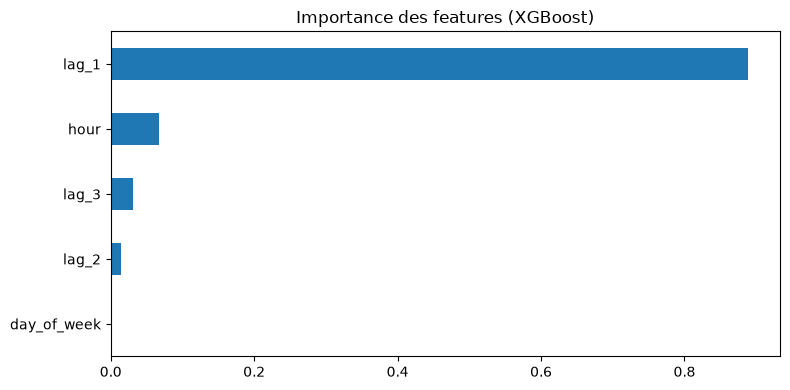

In [14]:
import matplotlib.pyplot as plt

if len(train) > 10 and len(test) > 0:
    importances = pd.Series(model.feature_importances_, index=features).sort_values()
    plt.figure(figsize=(8, 4))
    importances.plot(kind="barh")
    plt.title("Importance des features (XGBoost)")
    plt.tight_layout()
    plt.show()

## 6. Sauvegarde du modèle

In [15]:
import joblib
import os

if len(train) > 10 and len(test) > 0:
    os.makedirs("../ml_models", exist_ok=True)
    joblib.dump(model, "../ml_models/xgb_baseline.joblib")
    print("Modèle sauvegardé dans ml_models/xgb_baseline.joblib")

Modèle sauvegardé dans ml_models/xgb_baseline.joblib


## Prochaine étape

- Relancer ce notebook régulièrement (plus de données = meilleur modèle)
- Ajouter la météo comme feature (Open-Meteo, URL déjà dans le `.env`)
- Tester plusieurs horizons de prédiction (15 min, 30 min, 1h)
- Une fois satisfait de la performance : brancher ce modèle dans l'API
  (endpoint `/predict/{station_id}`)